# Full-posterior standardised residuals

Reconstructs the standardised residuals of the AR(2) base model (per 10,000 population)
from the **full posterior**, not the posterior mean.

For each posterior draw the mean `mu`, fitted value `fullmod` (AR(2)) and residual
`y - fullmod` are rebuilt from `raw_samples.csv`, then standardised by the region
precision: `z = resid * sqrt(tau_i)`. The per-week posterior mean of `z` is saved and plotted.

Sources are hard-coded to `data/models/wide_weekly_scaledPer10k/v4.6/`.


In [1]:
import sys
sys.path.insert(0, "../..")            # project root, for the indicator builders

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyjags_pipeline.data import load_observed, build_event_indicators, build_ny_indicators_by_date

# Hard-coded sources: AR(2) base model, per 10,000 population
RAW  = "../../data/models/wide_weekly_scaledPer10k/v4.6/raw_samples.csv"
DATA = "data/wide_weekly_scaledPer10k.csv"   # load_observed resolves this from the project root

df_wide, regions, n_region, n_weeks, y = load_observed(DATA)
dates = list(df_wide.columns)
ev    = build_event_indicators(n_weeks, regions)
ny    = build_ny_indicators_by_date(dates)
draws = pd.read_csv(RAW)
print(f"{len(draws)} draws, {n_region} regions, {n_weeks} weeks")

80000 draws, 6 regions, 170 weeks


In [2]:
# For each draw: mu -> fullmod (AR(2)) -> resid = y - fullmod -> z = resid * sqrt(tau_i)
t     = np.arange(1, n_weeks + 1)
cos52 = np.cos(2 * np.pi * t / 52)
sin52 = np.sin(2 * np.pi * t / 52)
mw    = ev["mw"]

sigma      = np.column_stack([draws[f"sigma_w{k}"] for k in range(1, 6)])  # (draws, 5)
fr3        = np.column_stack([ev[f"fr3_w{k}"] for k in range(1, 6)])       # (weeks, 5)
mw_block   = sigma @ fr3.T                                                 # (draws, weeks)
phi1, phi2 = draws["phi1"].values, draws["phi2"].values

std_resid = np.zeros((n_weeks, n_region))
for i, region in enumerate(regions):
    a     = draws[f"alpha[{i+1}]"].values
    b     = draws[f"beta[{i+1}]"].values
    g     = draws[f"gamma[{i+1}]"].values
    dpm1  = draws[f"delta_pm1[{i+1}]"].values
    dpre  = draws[f"delta_pre[{i+1}]"].values
    dmid  = draws[f"delta_mid[{i+1}]"].values
    dpost = draws[f"delta_post[{i+1}]"].values
    tau   = draws[f"tau[{i+1}]"].values

    mu = (a[:, None]
          + b[:, None] * cos52 + g[:, None] * sin52
          + dpm1[:, None] * ny["ny_pm1"] + dpre[:, None] * ny["ny_pre"]
          + dmid[:, None] * ny["ny_mid"] + dpost[:, None] * ny["ny_post"]
          + mw[i] * mw_block)

    yi = y[i]
    fm = np.empty_like(mu)
    fm[:, 0] = mu[:, 0]
    fm[:, 1] = mu[:, 1] + phi1 * (yi[0] - mu[:, 0])
    for k in range(2, n_weeks):
        fm[:, k] = mu[:, k] + phi1 * (yi[k-1] - mu[:, k-1]) + phi2 * (yi[k-2] - mu[:, k-2])

    z = (yi[None, :] - fm) * np.sqrt(tau)[:, None]   # standardised residual per draw
    std_resid[:, i] = z.mean(axis=0)                 # posterior mean

out = pd.DataFrame(std_resid, columns=regions)
out.insert(0, "week", dates)
out.to_csv("standardised_residuals.csv", index=False)
out.head()

,week,HSE Dublin and Midlands,HSE Dublin and North East,HSE Dublin and South East,HSE Mid West,HSE South West,HSE West and North West
0,2023-01-02,2.497092,2.612943,3.076931,-0.799478,0.285248,1.468907
1,2023-01-09,-0.652995,-1.109592,-0.962042,-2.523610,-0.912167,-1.852860
2,2023-01-16,-0.189185,-1.659163,-1.333600,-0.536123,-0.265852,1.180808
3,2023-01-23,-1.216088,-1.218493,-0.019458,-1.222837,0.655298,-0.912460
4,2023-01-30,-0.020403,-1.138021,-0.803825,0.032937,-0.546858,-0.625177


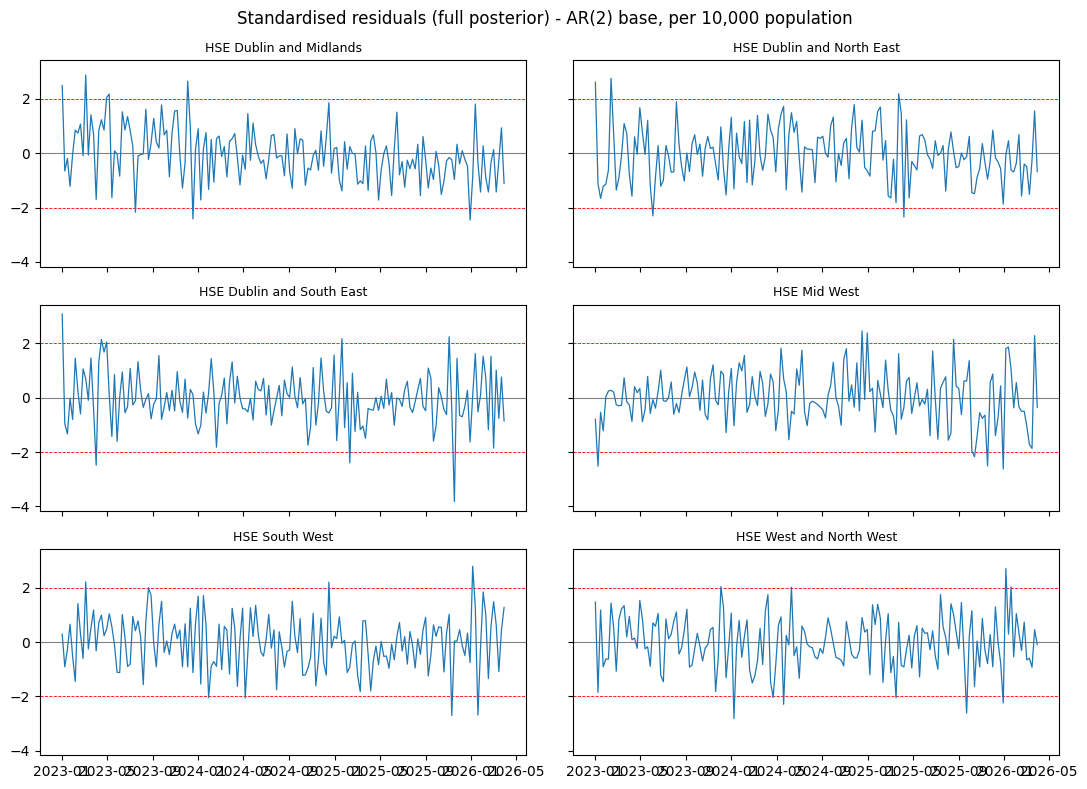

In [3]:
x = pd.to_datetime(dates)
fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, region in zip(axes.ravel(), regions):
    ax.axhline(0, color="grey", lw=0.8)
    ax.axhline(2, color="red", lw=0.6, ls="--")
    ax.axhline(-2, color="red", lw=0.6, ls="--")
    ax.plot(x, out[region], lw=0.9)
    ax.set_title(region, fontsize=9)
fig.suptitle("Standardised residuals (full posterior) - AR(2) base, per 10,000 population")
fig.tight_layout()
fig.savefig("standardised_residuals.png", dpi=150)
plt.show()